<a href="https://colab.research.google.com/github/snig0708/stock_price_prediction/blob/main/stock_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [95]:
import os
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

In [96]:
# ======================
# CONFIG
# ======================
DATA_PATH = "/content/data/stock_data.csv"
TARGET_STOCK = None  # Select the stock you want to study...

SEQ_LENGTH = 10
BATCH_SIZE = 64
EPOCHS = 20
LR = 0.001
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15   # test will be remaining 0.15

SEED = 42

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Using device:", device)

Using device: cuda


In [97]:
# Loading the dataset

df_raw = pd.read_csv(DATA_PATH)
print("Shape:", df_raw.shape)
display(df_raw.head())
print(df_raw.columns.tolist())

Shape: (365, 6)


,Unnamed: 0,Stock_1,Stock_2,Stock_3,Stock_4,Stock_5
0,2020-01-01,101.764052,100.160928,99.494642,99.909756,101.761266
1,2020-01-02,102.171269,99.969968,98.682973,100.640755,102.528643
2,2020-01-03,103.171258,99.575237,98.182139,100.574847,101.887811
3,2020-01-04,105.483215,99.308641,97.149381,100.925017,101.490049
4,2020-01-05,107.453175,98.188428,99.575396,101.594411,101.604283


['Unnamed: 0', 'Stock_1', 'Stock_2', 'Stock_3', 'Stock_4', 'Stock_5']


In [98]:
# Since, first column is date and remaining columns are stock price series
date_col = df_raw.columns[0]
df = df_raw.copy()

df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
df = df.dropna(subset=[date_col]).sort_values(date_col).reset_index(drop=True)
df = df.set_index(date_col)


# Keep only numeric stock columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

if len(numeric_cols) == 0:
    raise ValueError("No numeric stock columns found. Please inspect the dataset.")

if TARGET_STOCK is None:
    TARGET_STOCK = numeric_cols[0]

if TARGET_STOCK not in numeric_cols:
    raise ValueError(f"{TARGET_STOCK} not found in numeric stock columns: {numeric_cols[:10]}")

print("Chosen stock:", TARGET_STOCK)
print("Number of stock columns:", len(numeric_cols))
print("Sample stock columns:", numeric_cols[:10])

series_df = df[[TARGET_STOCK]].rename(columns={TARGET_STOCK: "close"}).copy()
series_df = series_df.dropna()

display(series_df.head())

Chosen stock: Stock_1
Number of stock columns: 5
Sample stock columns: ['Stock_1', 'Stock_2', 'Stock_3', 'Stock_4', 'Stock_5']


,close
Unnamed: 0,
2020-01-01,101.764052
2020-01-02,102.171269
2020-01-03,103.171258
2020-01-04,105.483215
2020-01-05,107.453175


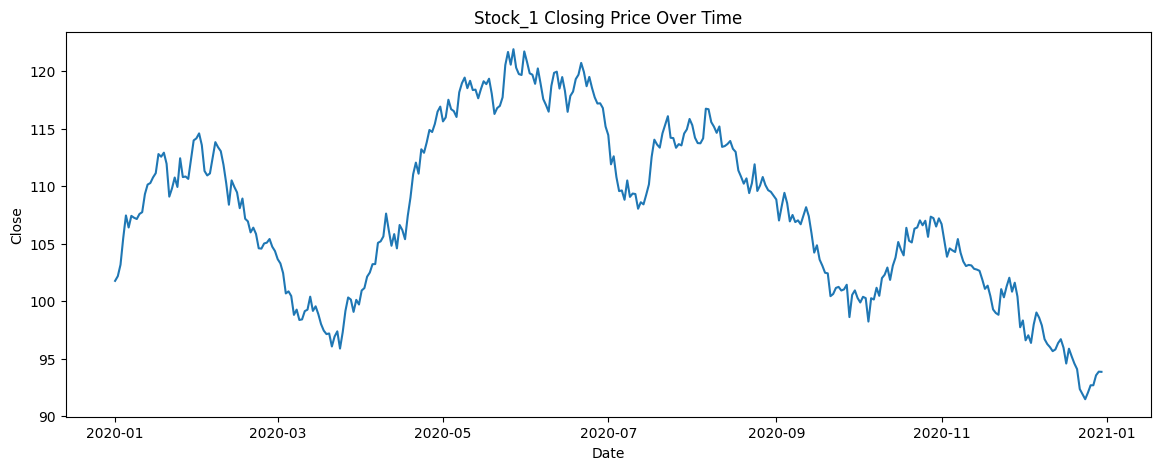

In [99]:
plt.figure(figsize=(14, 5))
plt.plot(series_df.index, series_df["close"])
plt.title(f"{TARGET_STOCK} Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Close")
plt.show()

In [100]:
### Feature Engineering

df_features = series_df.copy()

# Returns and rolling features
df_features["return_1d"] = df_features["close"].pct_change()
df_features["ma_5"] = df_features["close"].rolling(5).mean()
df_features["ma_20"] = df_features["close"].rolling(20).mean()
df_features["volatility_5"] = df_features["return_1d"].rolling(5).std()

# Calendar features from date index
df_features["day_of_week"] = df_features.index.dayofweek
df_features["month"] = df_features.index.month

# Cyclical encoding
df_features["sin_day_of_week"] = np.sin(2 * np.pi * df_features["day_of_week"] / 7)
df_features["cos_day_of_week"] = np.cos(2 * np.pi * df_features["day_of_week"] / 7)

df_features["sin_month"] = np.sin(2 * np.pi * (df_features["month"] - 1) / 12)
df_features["cos_month"] = np.cos(2 * np.pi * (df_features["month"] - 1) / 12)

# Drop raw cyclical integer columns after encoding
df_features = df_features.drop(columns=["day_of_week", "month"])

# Drop rows with NaN from rolling calculations
df_features = df_features.dropna().copy()

####df_features["target"] = df_features["close"].pct_change()

display(df_features.head())
print(df_features.shape)

,close,return_1d,ma_5,ma_20,volatility_5,sin_day_of_week,cos_day_of_week,sin_month,cos_month
Unnamed: 0,,,,,,,,,
2020-01-20,111.944164,-0.008541,112.264707,108.267710,0.008630,0.000000,1.000000,0.0,1.0
2020-01-21,109.086241,-0.025530,111.856515,108.633819,0.014973,0.781831,0.623490,0.0,1.0
2020-01-22,109.799249,0.006536,111.258860,109.015219,0.012664,0.974928,-0.222521,0.0,1.0
2020-01-23,110.748393,0.008644,110.897312,109.394075,0.014162,0.433884,-0.900969,0.0,1.0
2020-01-24,109.926458,-0.007422,110.300901,109.616237,0.013773,-0.433884,-0.900969,0.0,1.0


(346, 9)


In [101]:
### Train and Validation Splits by time

n = len(df_features)
train_end = int(n * TRAIN_RATIO)
val_end = int(n * (TRAIN_RATIO + VAL_RATIO))

train_df = df_features.iloc[:train_end].copy()
val_df = df_features.iloc[train_end:val_end].copy()
test_df = df_features.iloc[val_end:].copy()

print("Train:", train_df.shape)
print("Val:", val_df.shape)
print("Test:", test_df.shape)

Train: (242, 9)
Val: (52, 9)
Test: (52, 9)


In [102]:
### Scaling the features

feature_cols = df_features.columns.tolist()
target_col = "close"
target_idx = feature_cols.index(target_col)

scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train_df[feature_cols])
val_scaled = scaler.transform(val_df[feature_cols])
test_scaled = scaler.transform(test_df[feature_cols])

print("Feature columns:", feature_cols)
print("Target index:", target_idx)

Feature columns: ['close', 'return_1d', 'ma_5', 'ma_20', 'volatility_5', 'sin_day_of_week', 'cos_day_of_week', 'sin_month', 'cos_month']
Target index: 0


In [103]:
### Creating the sequences for the model(s)

def create_sequences(data, seq_length, target_idx=0):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])
        y.append(data[i + seq_length, target_idx])
    return np.array(X), np.array(y).reshape(-1, 1)

X_train, y_train = create_sequences(train_scaled, SEQ_LENGTH, target_idx=target_idx)
X_val, y_val = create_sequences(val_scaled, SEQ_LENGTH, target_idx=target_idx)
X_test, y_test = create_sequences(test_scaled, SEQ_LENGTH, target_idx=target_idx)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:", X_val.shape, "y_val:", y_val.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)

X_train: (232, 10, 9) y_train: (232, 1)
X_val: (42, 10, 9) y_val: (42, 1)
X_test: (42, 10, 9) y_test: (42, 1)


In [104]:
### Convert to PyTorch tensors

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)

X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False)

INPUT_SIZE = X_train.shape[2]
print("Input size:", INPUT_SIZE)

Input size: 9


In [105]:
### Defining the models


HIDDEN_SIZE = 128
NUM_LAYERS = 2

class RNNModel(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size, device=x.device)
        out, _ = self.rnn(x, h0)
        return self.fc(out[:, -1, :])


class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size, device=x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size, device=x.device)
        out, _ = self.lstm(x, (h0, c0))
        return self.fc(out[:, -1, :])


class GRUModel(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size, device=x.device)
        out, _ = self.gru(x, h0)
        return self.fc(out[:, -1, :])

In [106]:
### Training and Evaluation helpers

def inverse_transform_target(values, scaler, feature_count, target_idx):
    temp = np.zeros((len(values), feature_count))
    temp[:, target_idx] = values.reshape(-1)
    inv = scaler.inverse_transform(temp)
    return inv[:, target_idx].reshape(-1, 1)


def evaluate_regression(actuals, preds):
    mae = mean_absolute_error(actuals, preds)
    rmse = np.sqrt(mean_squared_error(actuals, preds))
    return mae, rmse


def directional_accuracy_from_last_close(last_close, actual_next, pred_next):
    actual_move = actual_next.reshape(-1) - last_close.reshape(-1)
    pred_move = pred_next.reshape(-1) - last_close.reshape(-1)

    actual_dir = (actual_move > 0).astype(int)
    pred_dir = (pred_move > 0).astype(int)

    return (actual_dir == pred_dir).mean()


def train_model(model, train_loader, val_loader, epochs=40, lr=0.001):
    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_losses, val_losses = [], []
    best_val_loss = float("inf")
    best_state = None

    for epoch in range(epochs):
        model.train()
        total_train_loss = 0.0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()
            preds = model(X_batch)
            loss = criterion(preds, y_batch)
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        model.eval()
        total_val_loss = 0.0

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)

                preds = model(X_batch)
                loss = criterion(preds, y_batch)
                total_val_loss += loss.item()

        avg_val_loss = total_val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_state = model.state_dict()

        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.6f} | Val Loss: {avg_val_loss:.6f}")

    model.load_state_dict(best_state)
    return model, train_losses, val_losses


def predict_model(model, data_loader):
    model.eval()
    preds, actuals = [], []

    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch = X_batch.to(device)
            outputs = model(X_batch)

            preds.extend(outputs.cpu().numpy())
            actuals.extend(y_batch.numpy())

    return np.array(preds), np.array(actuals)

In [107]:
### Training the models

models = {
    "RNN": RNNModel(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS),
    "LSTM": LSTMModel(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS),
    "GRU": GRUModel(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS),
}

trained_models = {}
history = {}
results = []

for model_name, model in models.items():
    print(f"\nTraining {model_name}...")
    trained_model, train_losses, val_losses = train_model(
        model, train_loader, val_loader, epochs=EPOCHS, lr=LR
    )
    trained_models[model_name] = trained_model
    history[model_name] = {"train": train_losses, "val": val_losses}


Training RNN...
Epoch 1/20 | Train Loss: 0.118783 | Val Loss: 0.166038
Epoch 2/20 | Train Loss: 0.103571 | Val Loss: 0.007524
Epoch 3/20 | Train Loss: 0.058034 | Val Loss: 0.006922
Epoch 4/20 | Train Loss: 0.022130 | Val Loss: 0.016393
Epoch 5/20 | Train Loss: 0.023231 | Val Loss: 0.009082
Epoch 6/20 | Train Loss: 0.009248 | Val Loss: 0.009288
Epoch 7/20 | Train Loss: 0.013128 | Val Loss: 0.009774
Epoch 8/20 | Train Loss: 0.008941 | Val Loss: 0.005572
Epoch 9/20 | Train Loss: 0.005809 | Val Loss: 0.009465
Epoch 10/20 | Train Loss: 0.005275 | Val Loss: 0.012126
Epoch 11/20 | Train Loss: 0.004739 | Val Loss: 0.008355
Epoch 12/20 | Train Loss: 0.004358 | Val Loss: 0.009723
Epoch 13/20 | Train Loss: 0.003597 | Val Loss: 0.015335
Epoch 14/20 | Train Loss: 0.003498 | Val Loss: 0.013889
Epoch 15/20 | Train Loss: 0.003227 | Val Loss: 0.012138
Epoch 16/20 | Train Loss: 0.002809 | Val Loss: 0.012050
Epoch 17/20 | Train Loss: 0.002655 | Val Loss: 0.008296
Epoch 18/20 | Train Loss: 0.002497 | Val

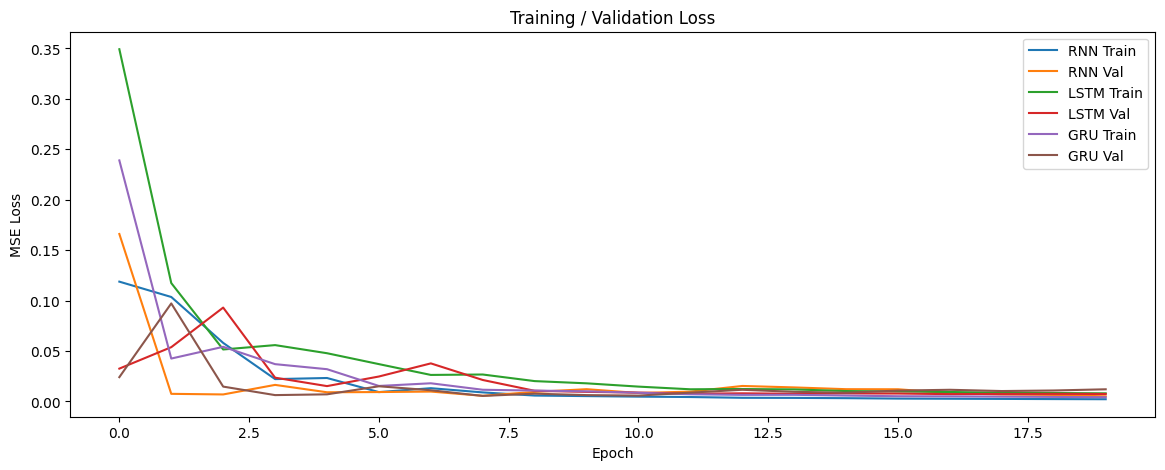

In [108]:
plt.figure(figsize=(14, 5))
for model_name, losses in history.items():
    plt.plot(losses["train"], label=f"{model_name} Train")
    plt.plot(losses["val"], label=f"{model_name} Val")
plt.title("Training / Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

In [109]:
### Evaluation on test set

for model_name, model in trained_models.items():
    preds_scaled, actuals_scaled = predict_model(model, test_loader)

    preds = inverse_transform_target(preds_scaled, scaler, len(feature_cols), target_idx)
    actuals = inverse_transform_target(actuals_scaled, scaler, len(feature_cols), target_idx)

    last_close_scaled = X_test[:, -1, target_idx].numpy().reshape(-1, 1)
    last_close = inverse_transform_target(last_close_scaled, scaler, len(feature_cols), target_idx)

    mae, rmse = evaluate_regression(actuals, preds)
    dacc = directional_accuracy_from_last_close(last_close, actuals, preds)

    results.append({
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "Directional_Accuracy": dacc
    })

In [112]:
### Baseline Comparison ...

# Naive baseline: predict tomorrow = today
actuals_baseline = inverse_transform_target(y_test.numpy(), scaler, len(feature_cols), target_idx)

# last close in each sequence
last_close_scaled = X_test[:, -1, target_idx].numpy().reshape(-1, 1)
last_close = inverse_transform_target(last_close_scaled, scaler, len(feature_cols), target_idx)

preds_baseline = last_close.copy()

baseline_mae, baseline_rmse = evaluate_regression(actuals_baseline, preds_baseline)
baseline_dacc = directional_accuracy_from_last_close(last_close, actuals_baseline, preds_baseline)

display(baseline_mae)
print(baseline_dacc)

0.8028586553348125

0.5952380952380952


Best model: RNN


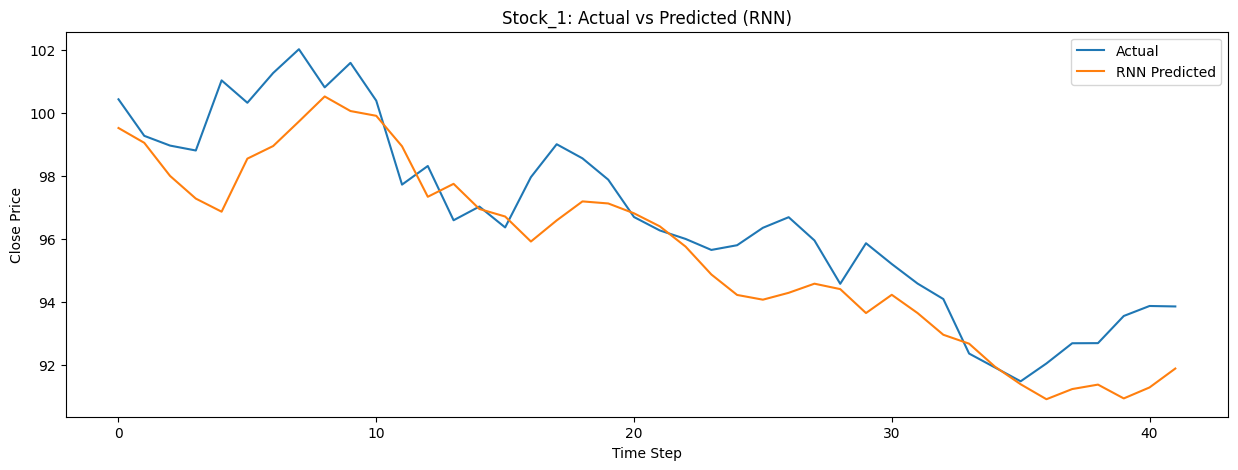

In [111]:
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

preds_scaled, actuals_scaled = predict_model(best_model, test_loader)
preds = inverse_transform_target(preds_scaled, scaler, len(feature_cols), target_idx)
actuals = inverse_transform_target(actuals_scaled, scaler, len(feature_cols), target_idx)

print("Best model:", best_model_name)

plt.figure(figsize=(15, 5))
plt.plot(actuals[:200], label="Actual")
plt.plot(preds[:200], label=f"{best_model_name} Predicted")
plt.title(f"{TARGET_STOCK}: Actual vs Predicted ({best_model_name})")
plt.xlabel("Time Step")
plt.ylabel("Close Price")
plt.legend()
plt.show()